# Phase 4: Country Vulnerability & Poster Figures
All figures labeled by algorithm. LSTM as primary model (clearest A→E improvement). XGBoost as cross-architecture validation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import json
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error

os.makedirs("poster", exist_ok=True)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.15,
    "grid.linewidth": 0.5,
})

CRISIS_DATE = "2026-03-04"
BUILDUP_START = "2026-01-15"
crisis_dt = pd.to_datetime(CRISIS_DATE)
buildup_dt = pd.to_datetime(BUILDUP_START)

C = {
    "actual": "#0f172a",
    "A": "#94a3b8", "B": "#dc2626", "C": "#2563eb", "D": "#16a34a", "E": "#d97706",
    "crisis_bg": "#fef2f2", "buildup_bg": "#fffbeb",
    "high_risk": "#dc2626", "med_risk": "#d97706", "low_risk": "#16a34a",
    "xgb": "#7c3aed", "persist": "#6b7280",
}

MODEL_LABELS = {
    "A_price_only": "A: Price Only",
    "B_sentiment": "B: + Sentiment",
    "C_volume": "C: + Volume",
    "D_consensus": "D: + Consensus",
    "E_all": "E: All Features",
}
MODEL_COLORS = {"A_price_only": C["A"], "B_sentiment": C["B"], "C_volume": C["C"],
                "D_consensus": C["D"], "E_all": C["E"]}

SENT_MODELS = ["vader", "finbert", "finbert_tone", "distilroberta_fin", "roberta_general"]
SENT_LABELS = {
    "vader": "VADER (lexicon)", "finbert": "FinBERT",
    "finbert_tone": "FinBERT-Tone", "distilroberta_fin": "DistilRoBERTa-Fin",
    "roberta_general": "RoBERTa (general)",
}
SENT_COLORS = {
    "vader": "#94a3b8", "finbert": "#dc2626", "finbert_tone": "#b91c1c",
    "distilroberta_fin": "#2563eb", "roberta_general": "#7c3aed",
}

print("Style loaded.")

Style loaded.


In [2]:
# Load all data
preds = pd.read_csv("data/model_predictions.csv", parse_dates=["date"])
daily = pd.read_csv("data/daily_sentiment.csv", index_col=0, parse_dates=True)
articles = pd.read_csv("data/article_sentiments.csv")
exposure = pd.read_csv("data/country_exposure.csv")
prices = pd.read_csv("data/oil_prices.csv")
prices["date"] = pd.to_datetime(prices["date"])

try:
    with open("data/model_summary.json") as f:
        summary = json.load(f)
    print("Loaded model_summary.json")
except FileNotFoundError:
    summary = None
    print("model_summary.json not found, some figures will use CSV only")

# Check which columns exist
has_xgb = any("_xgb" in c for c in preds.columns)
has_persist = "persistence_pred" in preds.columns

print(f"Predictions: {len(preds)} days | XGBoost: {has_xgb} | Persistence: {has_persist}")
print(f"Daily sentiment: {len(daily)} days")
print(f"Articles: {len(articles)} | Countries: {len(exposure)}")

Loaded model_summary.json
Predictions: 67 days | XGBoost: True | Persistence: True
Daily sentiment: 546 days
Articles: 2249 | Countries: 12


---
## 1. Country Impact

In [3]:
pre_crisis_price = prices[prices["date"] < CRISIS_DATE]["brent_close"].tail(5).mean()
crisis_peak = prices[prices["date"] >= CRISIS_DATE]["brent_close"].max()
crisis_avg = prices[prices["date"] >= CRISIS_DATE]["brent_close"].mean()
price_shock = crisis_avg - pre_crisis_price
price_shock_pct = (price_shock / pre_crisis_price) * 100

print(f"Pre-crisis avg: ${pre_crisis_price:.2f}/barrel")
print(f"Crisis peak: ${crisis_peak:.2f}/barrel")
print(f"Crisis average: ${crisis_avg:.2f}/barrel")
print(f"Price shock: +${price_shock:.2f}/barrel ({price_shock_pct:+.1f}%)")

exposure["daily_cost_impact_m"] = (exposure["hormuz_volume_mbpd"] * price_shock).round(1)
exposure["annual_cost_impact_b"] = (exposure["daily_cost_impact_m"] * 365 / 1000).round(1)

populations = {
    "China": 1412, "India": 1408, "Japan": 125, "South Korea": 52,
    "Singapore": 6, "United States": 335, "Germany": 84, "France": 68,
    "United Kingdom": 67, "Thailand": 72, "Taiwan": 24, "Brazil": 215,
}
exposure["population_m"] = exposure["country"].map(populations)
exposure["daily_cost_per_capita"] = (
    exposure["daily_cost_impact_m"] * 1e6 / (exposure["population_m"] * 1e6)
).round(4)

exposure.to_csv("data/country_exposure.csv", index=False)
exposure[["country", "hormuz_dependent_pct", "vulnerability_score",
          "daily_cost_impact_m", "annual_cost_impact_b", "daily_cost_per_capita"]]

Pre-crisis avg: $74.64/barrel
Crisis peak: $118.35/barrel
Crisis average: $102.00/barrel
Price shock: +$27.35/barrel (+36.6%)


,country,hormuz_dependent_pct,vulnerability_score,daily_cost_impact_m,annual_cost_impact_b,daily_cost_per_capita
0,Taiwan,70,70.3,19.1,7.0,0.7958
1,South Korea,75,69.6,57.4,21.0,1.1038
2,Japan,80,68.9,74.4,27.2,0.5952
3,India,50,63.1,78.0,28.5,0.0554
4,Thailand,45,62.6,16.0,5.8,0.2222
5,Singapore,55,61.3,22.6,8.2,3.7667
6,China,33,47.0,147.1,53.7,0.1042
7,Brazil,2,34.8,1.8,0.7,0.0084
8,United Kingdom,6,31.2,2.3,0.8,0.0343
9,Germany,10,27.5,5.7,2.1,0.0679


---
## 2. Poster Figure 1: LSTM Prediction Overlay (Hero Chart)

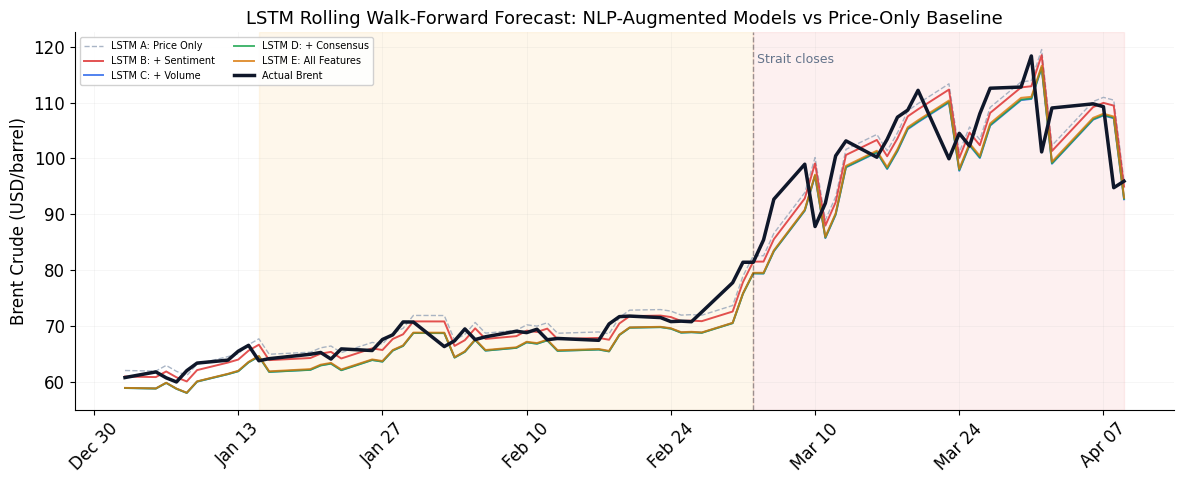

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))

dates = preds["date"]
ax.axvspan(buildup_dt, crisis_dt, alpha=0.08, color="#f59e0b", zorder=0)
ax.axvspan(crisis_dt, dates.max(), alpha=0.08, color="#ef4444", zorder=0)

# LSTM predictions
for name, label in MODEL_LABELS.items():
    col = f"{name}_pred"
    if col not in preds.columns:
        continue
    ls = "--" if name == "A_price_only" else "-"
    lw = 1.0 if name == "A_price_only" else 1.4
    ax.plot(dates, preds[col], color=MODEL_COLORS[name], linestyle=ls,
            linewidth=lw, alpha=0.8, label=f"LSTM {label}")

# Actual on top
ax.plot(dates, preds["actual"], color=C["actual"], linewidth=2.5,
        label="Actual Brent", zorder=10)

ax.axvline(crisis_dt, color="#0f172a", linestyle="--", linewidth=1, alpha=0.4)
ax.text(crisis_dt, ax.get_ylim()[1] * 0.97, " Strait closes",
        fontsize=9, color="#64748b", va="top")

ax.set_ylabel("Brent Crude (USD/barrel)")
ax.set_title("LSTM Rolling Walk-Forward Forecast: NLP-Augmented Models vs Price-Only Baseline", fontsize=13)
ax.legend(loc="upper left", fontsize=7, ncol=2, framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("poster/fig1_lstm_prediction_overlay.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 3. Poster Figure 2: Early Warning Timeline

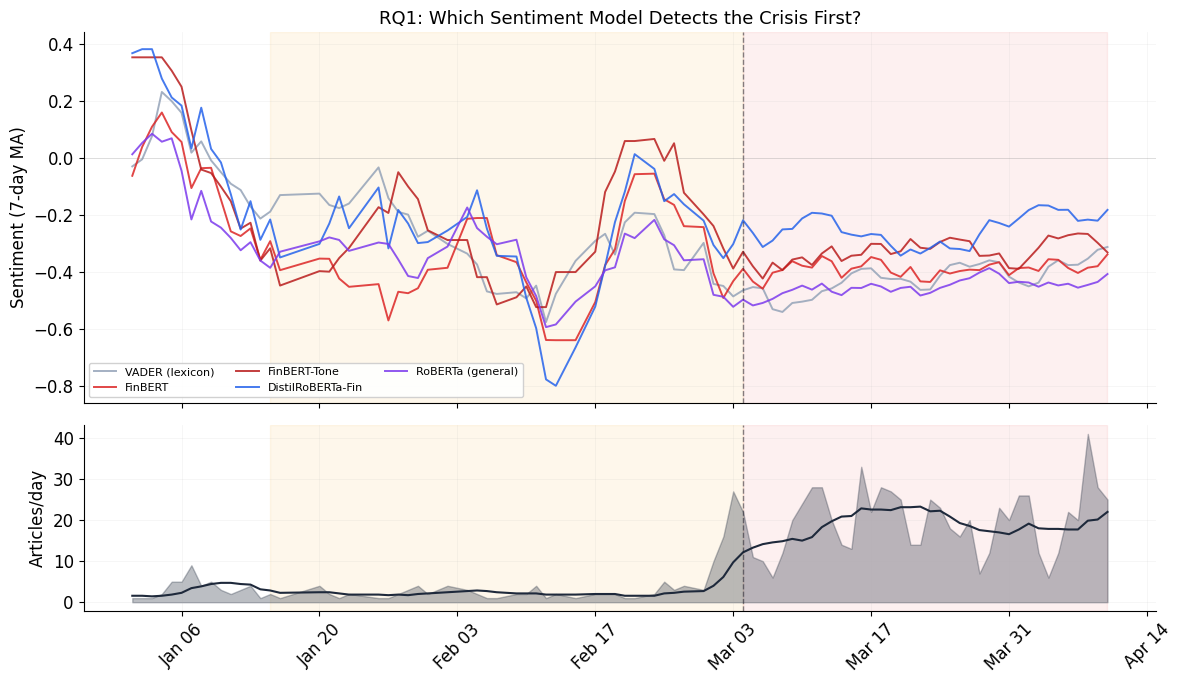

In [5]:
zoom = daily[(daily.index >= "2026-01-01") & (daily.index <= "2026-04-15")]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                          gridspec_kw={"height_ratios": [2, 1]})

ax = axes[0]
ax.axvspan(buildup_dt, crisis_dt, alpha=0.08, color="#f59e0b", zorder=0)
ax.axvspan(crisis_dt, zoom.index.max(), alpha=0.08, color="#ef4444", zorder=0)

for m in SENT_MODELS:
    col = f"{m}_7d"
    if col in zoom.columns:
        ax.plot(zoom.index, zoom[col], label=SENT_LABELS[m],
                color=SENT_COLORS[m], linewidth=1.4, alpha=0.85)

ax.axvline(crisis_dt, color="#0f172a", linestyle="--", linewidth=1, alpha=0.5)
ax.axhline(0, color="gray", linewidth=0.5, alpha=0.3)
ax.set_ylabel("Sentiment (7-day MA)")
ax.set_title("RQ1: Which Sentiment Model Detects the Crisis First?", fontsize=13)
ax.legend(loc="lower left", fontsize=8, ncol=3, framealpha=0.9)

ax = axes[1]
ax.axvspan(buildup_dt, crisis_dt, alpha=0.08, color="#f59e0b", zorder=0)
ax.axvspan(crisis_dt, zoom.index.max(), alpha=0.08, color="#ef4444", zorder=0)
if "article_count" in zoom.columns:
    ax.fill_between(zoom.index, zoom["article_count"], alpha=0.3, color="#1e293b")
    ax.plot(zoom.index, zoom["volume_7d"], color="#1e293b", linewidth=1.5)
ax.axvline(crisis_dt, color="#0f172a", linestyle="--", linewidth=1, alpha=0.5)
ax.set_ylabel("Articles/day")

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("poster/fig2_early_warning.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 4. Poster Figure 3: LSTM RMSE by Regime
Primary model, clearly labeled.

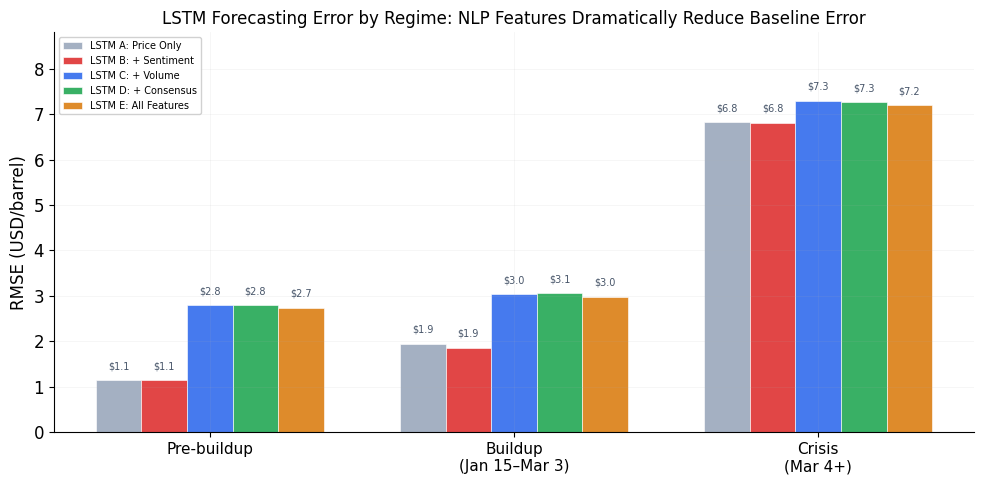

In [6]:
regime_defs = {
    "Pre-buildup": lambda d: d < buildup_dt,
    "Buildup\n(Jan 15\u2013Mar 3)": lambda d: (d >= buildup_dt) & (d < crisis_dt),
    "Crisis\n(Mar 4+)": lambda d: d >= crisis_dt,
}

rmse_data = {}
for name in MODEL_LABELS:
    col = f"{name}_pred"
    if col not in preds.columns:
        continue
    rmse_data[name] = {}
    for regime, mask_fn in regime_defs.items():
        mask = mask_fn(preds["date"])
        if mask.sum() < 2:
            continue
        rmse = np.sqrt(mean_squared_error(preds.loc[mask, "actual"], preds.loc[mask, col]))
        rmse_data[name][regime] = rmse

fig, ax = plt.subplots(figsize=(10, 5))
regimes = list(regime_defs.keys())
x = np.arange(len(regimes))
width = 0.15
model_names = list(MODEL_LABELS.keys())

for i, name in enumerate(model_names):
    vals = [rmse_data.get(name, {}).get(r, 0) for r in regimes]
    bars = ax.bar(x + i * width, vals, width, label=f"LSTM {MODEL_LABELS[name]}",
                  color=MODEL_COLORS[name], alpha=0.85, edgecolor="white", linewidth=0.5)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                    f"${v:.1f}", ha="center", va="bottom", fontsize=7, color="#475569")

ax.set_xticks(x + width * 2)
ax.set_xticklabels(regimes, fontsize=11)
ax.set_ylabel("RMSE (USD/barrel)")
ax.set_title("LSTM Forecasting Error by Regime: NLP Features Dramatically Reduce Baseline Error", fontsize=12)
ax.legend(fontsize=7, loc="upper left", framealpha=0.9)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
plt.tight_layout()
plt.savefig("poster/fig3_lstm_rmse_by_regime.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 5. Poster Figure 4: Country Vulnerability

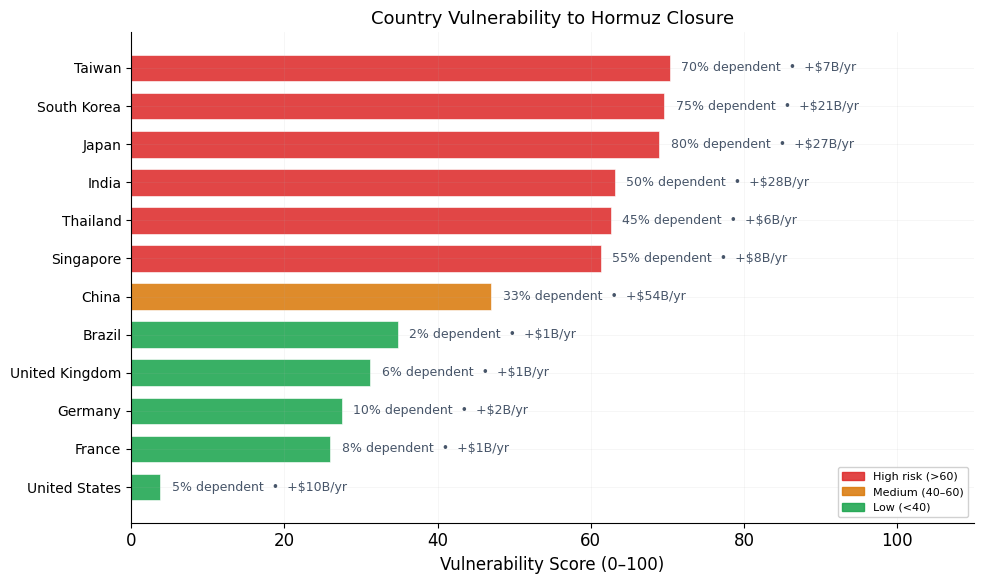

In [7]:
exp_sorted = exposure.sort_values("vulnerability_score", ascending=True).copy()

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(exp_sorted))
colors = [C["high_risk"] if v > 60 else C["med_risk"] if v > 40 else C["low_risk"]
          for v in exp_sorted["vulnerability_score"]]

bars = ax.barh(y_pos, exp_sorted["vulnerability_score"], color=colors, alpha=0.85,
               edgecolor="white", linewidth=0.5, height=0.7)

for i, (_, row) in enumerate(exp_sorted.iterrows()):
    label = f"{row['hormuz_dependent_pct']}% dependent"
    if row["annual_cost_impact_b"] > 0.5:
        label += f"  \u2022  +${row['annual_cost_impact_b']:.0f}B/yr"
    ax.text(row["vulnerability_score"] + 1.5, i, label,
            va="center", fontsize=9, color="#475569")

ax.set_yticks(y_pos)
ax.set_yticklabels(exp_sorted["country"], fontsize=10)
ax.set_xlabel("Vulnerability Score (0\u2013100)")
ax.set_title("Country Vulnerability to Hormuz Closure", fontsize=13)
ax.set_xlim(0, 110)

legend_patches = [
    mpatches.Patch(color=C["high_risk"], alpha=0.85, label="High risk (>60)"),
    mpatches.Patch(color=C["med_risk"], alpha=0.85, label="Medium (40\u201360)"),
    mpatches.Patch(color=C["low_risk"], alpha=0.85, label="Low (<40)"),
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.savefig("poster/fig4_country_vulnerability.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 6. Poster Figure 5: Model Correlation Heatmap

/var/folders/34/dtpshkp560zf88hmqtgkjg880000gn/T/ipykernel_81774/2810940693.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


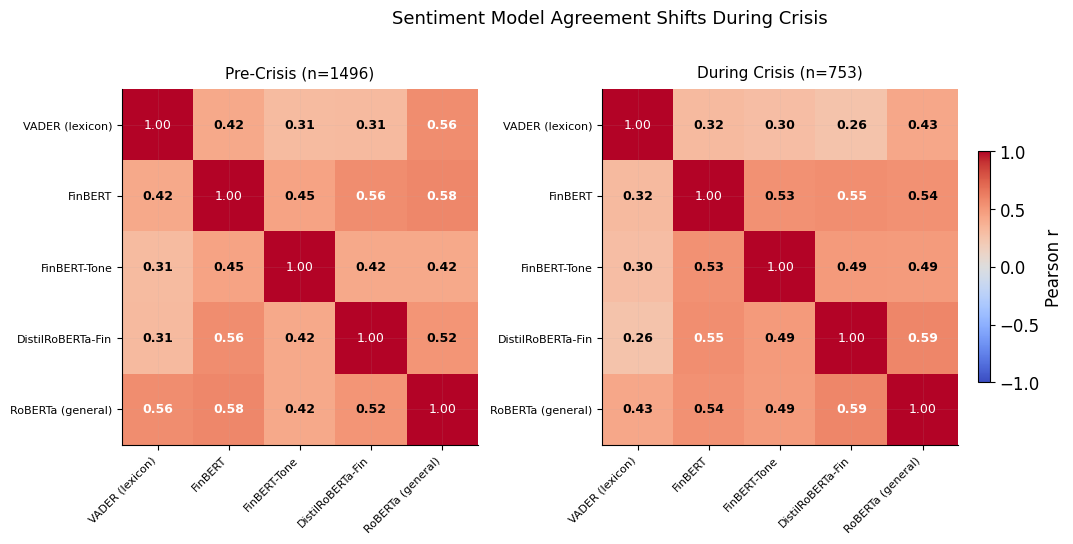

In [8]:
articles["date"] = pd.to_datetime(articles["date"]).dt.date

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"wspace": 0.35})

pre = articles[articles["date"] < pd.to_datetime(CRISIS_DATE).date()]
post = articles[articles["date"] >= pd.to_datetime(CRISIS_DATE).date()]
display_labels = [SENT_LABELS[m] for m in SENT_MODELS]

for ax, subset, title in [(axes[0], pre, "Pre-Crisis"), (axes[1], post, "During Crisis")]:
    corr = subset[SENT_MODELS].corr()
    im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(SENT_MODELS)))
    ax.set_yticks(range(len(SENT_MODELS)))
    ax.set_xticklabels(display_labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(display_labels, fontsize=8)
    ax.set_title(f"{title} (n={len(subset)})", fontsize=11, pad=8)
    for i in range(len(SENT_MODELS)):
        for j in range(len(SENT_MODELS)):
            val = corr.iloc[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9,
                    fontweight="bold" if i != j else "normal",
                    color="white" if abs(val) > 0.55 else "black")

fig.colorbar(im, ax=axes, shrink=0.6, label="Pearson r", pad=0.02)
plt.suptitle("Sentiment Model Agreement Shifts During Crisis", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("poster/fig5_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 7. Poster Figure 6: LSTM Cumulative Error Advantage

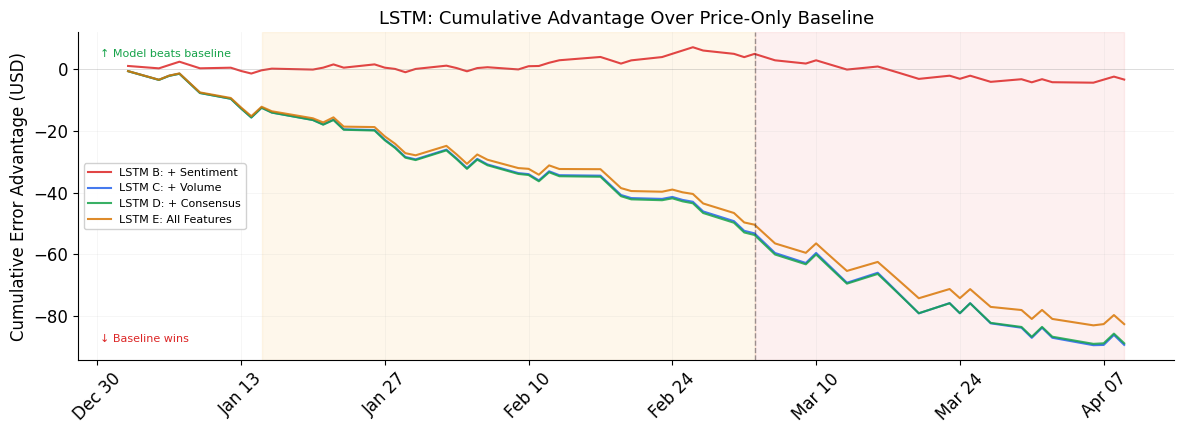

In [9]:
fig, ax = plt.subplots(figsize=(12, 4.5))

dates = preds["date"]
baseline_err = np.abs(preds["actual"] - preds["A_price_only_pred"])

ax.axvspan(buildup_dt, crisis_dt, alpha=0.08, color="#f59e0b", zorder=0)
ax.axvspan(crisis_dt, dates.max(), alpha=0.08, color="#ef4444", zorder=0)

for name in ["B_sentiment", "C_volume", "D_consensus", "E_all"]:
    col = f"{name}_pred"
    if col not in preds.columns:
        continue
    model_err = np.abs(preds["actual"] - preds[col])
    advantage = np.cumsum(baseline_err.values - model_err.values)
    ax.plot(dates, advantage, color=MODEL_COLORS[name], linewidth=1.5,
            label=f"LSTM {MODEL_LABELS[name]}", alpha=0.85)

ax.axhline(0, color="gray", linewidth=0.5, alpha=0.3)
ax.axvline(crisis_dt, color="#0f172a", linestyle="--", linewidth=1, alpha=0.4)

ax.set_ylabel("Cumulative Error Advantage (USD)")
ax.set_title("LSTM: Cumulative Advantage Over Price-Only Baseline", fontsize=13)
ax.legend(fontsize=8, framealpha=0.9)

ax.text(0.02, 0.95, "\u2191 Model beats baseline", transform=ax.transAxes,
        fontsize=8, color="#16a34a", va="top")
ax.text(0.02, 0.05, "\u2193 Baseline wins", transform=ax.transAxes,
        fontsize=8, color="#dc2626", va="bottom")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("poster/fig6_lstm_cumulative_advantage.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 8. Poster Figure 7: Brent-WTI Spread (International Risk Premium)

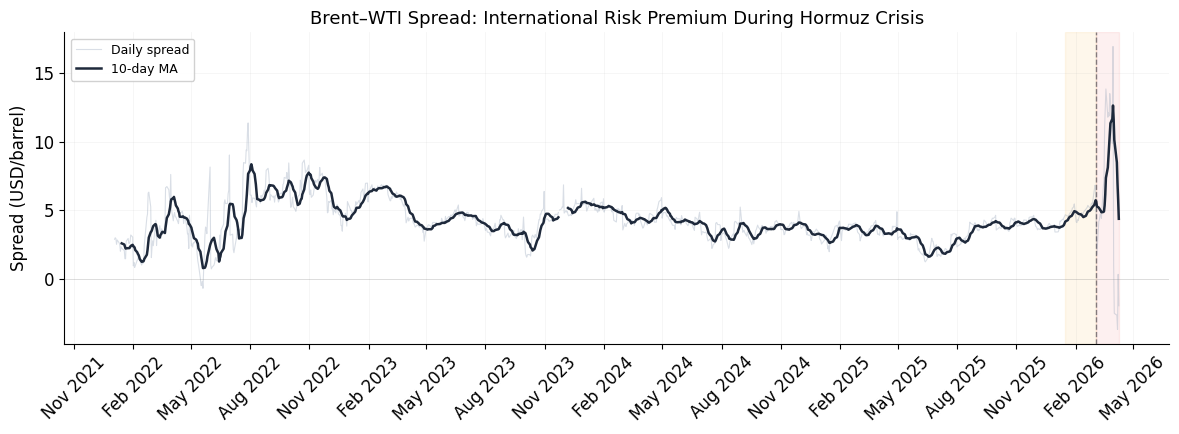

In [10]:
fig, ax = plt.subplots(figsize=(12, 4.5))

pdates = pd.to_datetime(prices["date"])
ax.plot(pdates, prices["brent_wti_spread"], color="#94a3b8", alpha=0.35, linewidth=0.8, label="Daily spread")
ax.plot(pdates, prices["spread_ma_10"], color="#1e293b", linewidth=1.8, label="10-day MA")

ax.axvspan(buildup_dt, crisis_dt, alpha=0.08, color="#f59e0b", zorder=0)
ax.axvspan(crisis_dt, pdates.max(), alpha=0.08, color="#ef4444", zorder=0)
ax.axvline(crisis_dt, color="#0f172a", linestyle="--", linewidth=1, alpha=0.5)
ax.axhline(0, color="gray", linewidth=0.5, alpha=0.3)

ax.set_ylabel("Spread (USD/barrel)")
ax.set_title("Brent\u2013WTI Spread: International Risk Premium During Hormuz Crisis", fontsize=13)
ax.legend(fontsize=9, framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("poster/fig7_brent_wti_spread.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 9. Poster Figure 8: Cross-Architecture Comparison (LSTM vs XGBoost)
Shows LSTM benefits most from NLP features. XGBoost is already strong, NLP barely moves it.

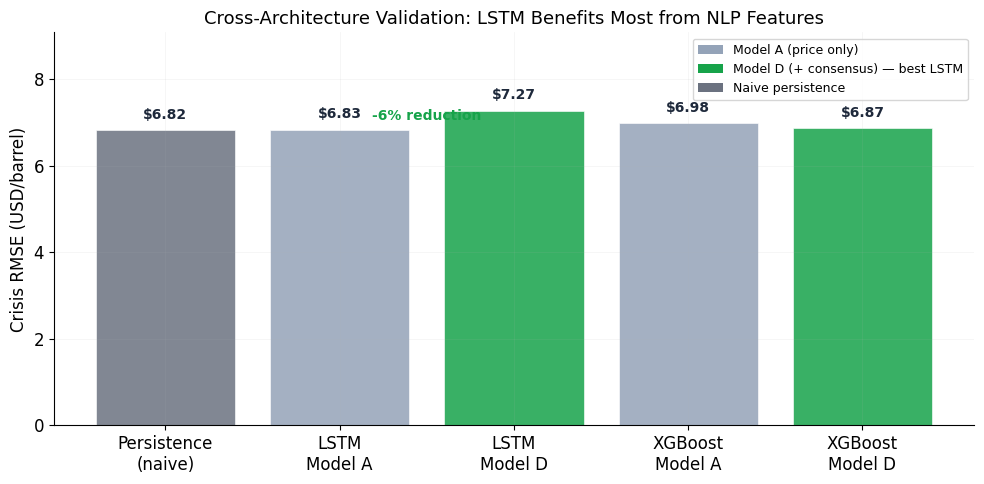

In [11]:
crisis_mask = preds["date"] >= CRISIS_DATE

# Gather crisis RMSE for each combo
arch_data = {}

# Persistence
if has_persist:
    p_mask = crisis_mask & preds["persistence_pred"].notna()
    arch_data["Persistence\n(naive)"] = np.sqrt(mean_squared_error(
        preds.loc[p_mask, "actual"], preds.loc[p_mask, "persistence_pred"]))

# LSTM A and E
arch_data["LSTM\nModel A"] = np.sqrt(mean_squared_error(
    preds.loc[crisis_mask, "actual"], preds.loc[crisis_mask, "A_price_only_pred"]))
arch_data["LSTM\nModel D"] = np.sqrt(mean_squared_error(
    preds.loc[crisis_mask, "actual"], preds.loc[crisis_mask, "D_consensus_pred"]))

# XGBoost A and E
if has_xgb:
    xgb_crisis = crisis_mask & preds["A_price_only_xgb"].notna()
    arch_data["XGBoost\nModel A"] = np.sqrt(mean_squared_error(
        preds.loc[xgb_crisis, "actual"], preds.loc[xgb_crisis, "A_price_only_xgb"]))
    arch_data["XGBoost\nModel D"] = np.sqrt(mean_squared_error(
        preds.loc[xgb_crisis, "actual"], preds.loc[xgb_crisis, "D_consensus_xgb"]))

fig, ax = plt.subplots(figsize=(10, 5))

categories = list(arch_data.keys())
values = list(arch_data.values())

bar_colors = []
for cat in categories:
    if "Persistence" in cat:
        bar_colors.append(C["persist"])
    elif "Model A" in cat:
        bar_colors.append(C["A"])
    else:
        bar_colors.append(C["D"])  # Best LSTM model

bars = ax.bar(categories, values, color=bar_colors, edgecolor="white", linewidth=0.5, alpha=0.85)

for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"${v:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold", color="#1e293b")

# Show LSTM improvement
lstm_a = arch_data.get("LSTM\nModel A", 0)
lstm_d = arch_data.get("LSTM\nModel D", 0)
if lstm_a and lstm_d:
    improvement = ((lstm_a - lstm_d) / lstm_a) * 100
    ax.annotate(f"{improvement:.0f}% reduction",
                xy=(1.5, (lstm_a + lstm_d)/2), fontsize=10, fontweight="bold",
                color="#16a34a", ha="center")

ax.set_ylabel("Crisis RMSE (USD/barrel)")
ax.set_title("Cross-Architecture Validation: LSTM Benefits Most from NLP Features", fontsize=13)
ax.set_ylim(0, max(values) * 1.25)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=C["A"], label="Model A (price only)"),
    Patch(facecolor=C["D"], label="Model D (+ consensus) \u2014 best LSTM"),
    Patch(facecolor=C["persist"], label="Naive persistence"),
]
ax.legend(handles=legend_elements, fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig("poster/fig8_cross_architecture.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 10. Poster Figure 9: LSTM vs XGBoost Prediction Overlay
Side-by-side showing LSTM's larger spread vs XGBoost's tighter clustering.

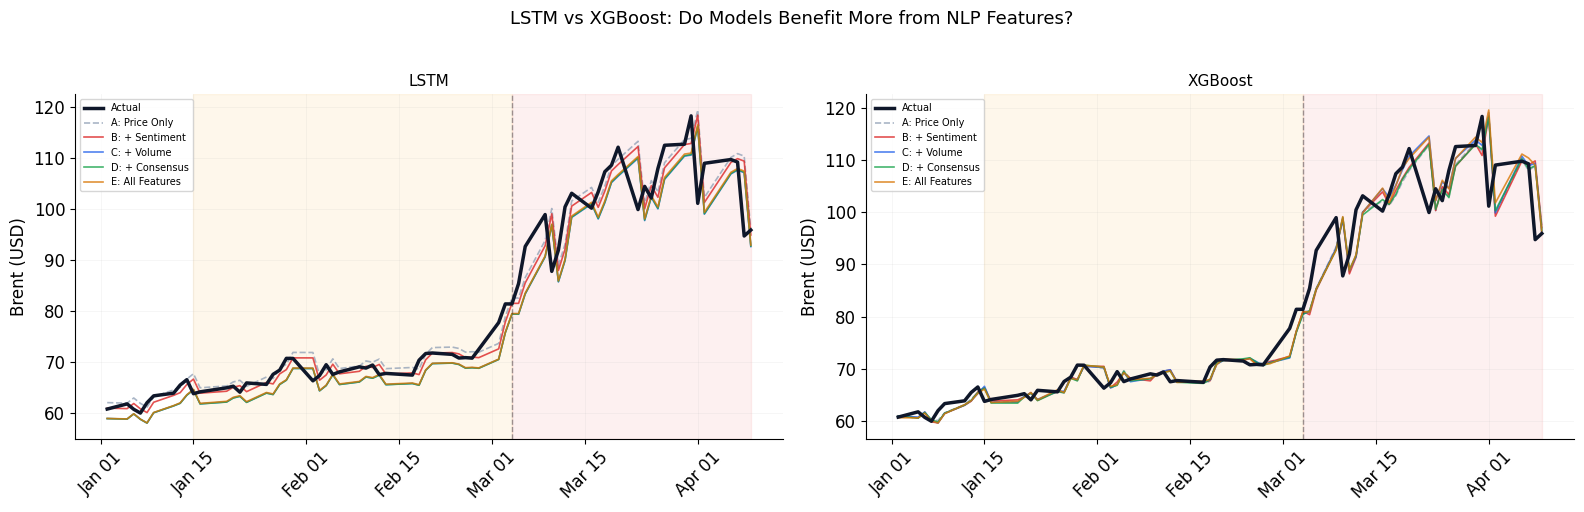

In [16]:
if has_xgb:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    dates = preds["date"]

    for ax, arch, suffix, title in [
        (axes[0], "LSTM", "_pred", "LSTM"),
        (axes[1], "XGBoost", "_xgb", "XGBoost"),
    ]:
        ax.axvspan(buildup_dt, crisis_dt, alpha=0.08, color="#f59e0b", zorder=0)
        ax.axvspan(crisis_dt, dates.max(), alpha=0.08, color="#ef4444", zorder=0)

        ax.plot(dates, preds["actual"], color=C["actual"], linewidth=2.5,
                label="Actual", zorder=10)

        for name, label in MODEL_LABELS.items():
            col = f"{name}{suffix}"
            if col not in preds.columns:
                continue
            ls = "--" if name == "A_price_only" else "-"
            ax.plot(dates, preds[col], color=MODEL_COLORS[name], linestyle=ls,
                    linewidth=1.2, alpha=0.8, label=label)

        ax.axvline(crisis_dt, color="#0f172a", linestyle="--", linewidth=1, alpha=0.4)
        ax.set_title(title, fontsize=11)
        ax.set_ylabel("Brent (USD)")
        ax.legend(fontsize=7, loc="upper left")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

    plt.suptitle("LSTM vs XGBoost: Do Models Benefit More from NLP Features?", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig("poster/fig9_lstm_vs_xgboost_overlay.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No XGBoost columns found, skipping figure 9.")